# *Tarea 2 inteligencia artificial*
## DCCasa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.tree import  DecisionTreeRegressor, plot_tree 
from sklearn.ensemble import RandomForestRegressor
import parametros

# *Parte 2.3.1.*

Cargamos los datos del csv al dataframe de pandas utilizando read_csv. Luego con el metodo describe podemos obtener un resumen estadistico de la columna `precio_uf` que es la variable objetivo. Observese la gran diferencia entre el valor maximo y el valor minimo, lo que indica una sospecha de valores atipicos. 


Para poder calcular la asimetria del atributo `precio_uf` ocupamos el merodo skew de pandas (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html)

In [2]:
df = pd.read_csv(parametros.BD_PROPIEDADES)
print(df["precio_en_uf"].describe())

asimetria = df["precio_en_uf"].skew()
print(f"Asimetria: {asimetria}")

count    20896.000000
mean      7583.554468
std       5186.321473
min          0.000408
25%       3450.000000
50%       6200.000000
75%      10490.000000
max      26000.000000
Name: precio_en_uf, dtype: float64
Asimetria: 1.1378122531956276


Como el valor de la simetria es mayor a 1, los datos presentan alta asimetria positiva. Lo que significa que existe una cola larga a la derecha, lo que implica que la mayoria de los datos, son valores bajos, pero existen valores muy altos, lo que se puede deber a la presencia de valores atipicos y como consecuencia, los datos no tienen un comportamiento normal. Esto se puede observar graficamente con un histograma o un grafico de estimacion de densidad  de kernel(kde). 

(Seaborn, s.f.) (GraphPad Software, s.f.)



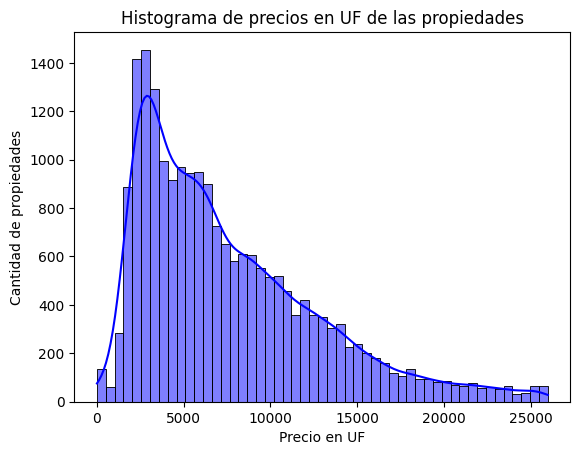

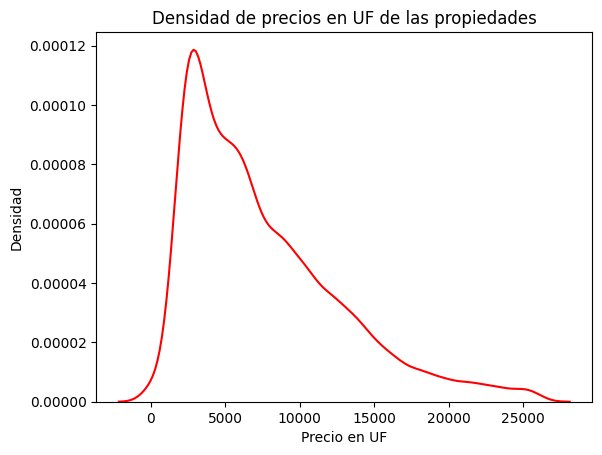

In [3]:
sns.histplot(df["precio_en_uf"], stat="count", kde=True, color = "blue")
plt.xlabel("Precio en UF")
plt.ylabel("Cantidad de propiedades")
plt.title("Histograma de precios en UF de las propiedades")
plt.show()


sns.kdeplot(df["precio_en_uf"], color = "red")
plt.xlabel("Precio en UF")
plt.ylabel("Densidad")
plt.title("Densidad de precios en UF de las propiedades")
plt.show()

Ocuparemos el metodo de los cuartiles para detectas estos valores atipicos. Esto debido a que por la asimetria, no podemos usar el metodo de Z valores porque los datos no son normales. (Asumiremos que no hay valores nulos en la columna precio_uf, y se comprobara posteriormente). Se puede observar que existen 525 valores atipicos mayores a la cota superior y 0 valores atipicos menores a la cota inferior. (GeeksforGeeks, s.f.)
(Sauro, s.f.)

La presencia de valores pueden afectar al modelo de aprendizaje ya que los resultados pueden estar sesgados por estos valores, lo que puede llevar a una mala generalización del modelo.

In [4]:
Q1 = df["precio_en_uf"].quantile(0.25)
Q3 = df["precio_en_uf"].quantile(0.75)

IQR = Q3 - Q1

cota_superior = Q3 + 1.5 * IQR
cota_inferior = Q1 - 1.5 * IQR
print(f"Cota superior: {cota_superior}")
print(f"Cota inferior: {cota_inferior}")

print(f"Cantidad de valores atipicos mayores a la cota superior: {len(df[df["precio_en_uf"] > cota_superior])}")

print(f"Cantidad de valores atipicos menores a la cota inferior: {len(df[df["precio_en_uf"] < cota_inferior])}")


Cota superior: 21050.0
Cota inferior: -7110.0
Cantidad de valores atipicos mayores a la cota superior: 525
Cantidad de valores atipicos menores a la cota inferior: 0


Entonces ahora eliminaremos de nuestro data frame los valores atipicos mayores a la cota superior, quedando un total de 525 filas eliminadas.

In [5]:
df = df[df["precio_en_uf"] <= cota_superior]

Además de esto, hay valores anormales en la columna `precio_uf` que son menores a 1, lo que no tiene sentido en el contexto de precios de propiedades. Por lo tanto, también eliminaremos estos valores anormales del dataframe. Haremos una cota inferior de al menos 1 para eliminar estos valores anormales. 

In [6]:
df = df[df["precio_en_uf"] >= 100]

Ahora, analicemos la precencia de valores faltantes. Utilizando df.info podemos observar que el atributo `id_provivencia`, se presenta como un dato `object`, lo cual es incorrecto ya que deberia ser un dato numerico (`int`). Y si observamos, podemos ver que contiene un str `<Null>` lo cual es un valor nulo pero en formato string, lo que genera que el atributo sea de tipo object. Esto tambien implica que posiblemente en otros atributos no se esten contando correctamente los valores nulos, ya que si se encuentran con un valor nulo en formato string, no lo contaran como nulo sino como un valor mas. Por lo tanto, es necesario convertir estos valores nulos en formato string a valores nulos reales para poder trabajar correctamente con el dataframe. Se ocupara el metodo `replace` para remplazar los valores str null por `np.nan` que es el valor nulo real en pandas.

In [7]:
print(f"Cantidad de filas del df: {len(df)}")
print(df.info())


Cantidad de filas del df: 20264
<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        20264 non-null  int64  
 1   id_tipo_propiedad         20264 non-null  int64  
 2   descripcion               20219 non-null  object 
 3   habitaciones              20264 non-null  int64  
 4   banos                     20264 non-null  int64  
 5   dimension_propiedad       20264 non-null  float64
 6   dimension_terreno         20264 non-null  float64
 7   direccion                 20218 non-null  object 
 8   direccion_2               20264 non-null  object 
 9   id_comuna                 20264 non-null  int64  
 10  id_provincia              20264 non-null  object 
 11  id_region                 20264 non-null  int64  
 12  id_antiguedad             20264 non-null  int64  
 13  year                      15847 no

Remplazamos los valores  str null por np.nan para poder trabajar correctamente con el dataframe. Luego, convertimos las columnas `"year", "id_provincia", "piso" y "estacionamientos"` a tipo de dato `Int64` (que es son enteros que aceptan valores nulos).

In [8]:
df = df.replace("<null>", np.nan)
df.info()
df["year"] = df["year"].astype("Int64")
df["id_provincia"] = df["id_provincia"].astype("Int64")
df["piso"] = df["piso"].astype("Int64")
df["estacionamientos"] = df["estacionamientos"].astype("Int64")




<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        20264 non-null  int64  
 1   id_tipo_propiedad         20264 non-null  int64  
 2   descripcion               19259 non-null  object 
 3   habitaciones              20264 non-null  int64  
 4   banos                     20264 non-null  int64  
 5   dimension_propiedad       20264 non-null  float64
 6   dimension_terreno         20264 non-null  float64
 7   direccion                 20218 non-null  object 
 8   direccion_2               12704 non-null  object 
 9   id_comuna                 20264 non-null  int64  
 10  id_provincia              20151 non-null  object 
 11  id_region                 20264 non-null  int64  
 12  id_antiguedad             20264 non-null  int64  
 13  year                      15847 non-null  float64
 14  gastos_comu

Se puede observar que existen valores faltantes en las columnas de `descripcion, direccion, direccion_2, year, gastos_comunes, piso, estacionamientos, cantidad_carectisticas `. Para poder conocer la cantidad valores faltantes de cada columna, se puede usar el metodo isnull y sum para contar la cantidad de valores faltantes por columna 
(Stack Overflow, s.f.)


`Posibles estrategias para tratar los valores faltantes`: Cambiar los valores faltantes por la media, mediana o moda de la columna. Esto puede ser util en todas las columnas numericas. En caso de las columnas categoticas, se puede ocupar la moda para rellenar con los datos faltantes.



In [9]:
print(df.isnull().sum())

id                              0
id_tipo_propiedad               0
descripcion                  1005
habitaciones                    0
banos                           0
dimension_propiedad             0
dimension_terreno               0
direccion                      46
direccion_2                  7560
id_comuna                       0
id_provincia                  113
id_region                       0
id_antiguedad                   0
year                         4417
gastos_comunes               4231
piso                        14422
estacionamientos             2173
amoblado                     2259
cantidad_caracteristicas    11100
precio_en_uf                    0
dtype: int64


Utilizando graficos de dispersión para analizar la relacion entre las variables `dimension_terreno`, `dimensión_propiedad`, `banos` y `habitaciones` con la variable objetivo `precio_uf`. Se puede observar que a medida que aumentan las dimensiones del terreno y de la propiedad, el precio en uf, tiende a aumentar, sin embargo, observe que para el primero, existe una gran cantidad de puntos con valores bajos de dimension_terreno y precios altos, y no se presenta una forma de diagonal clara, en otro caso, para el segundo, se puede observar una forma de diagonal más clara, lo que implica que existe una relación mucho más fuerte entre estas variables, por ende, la dimension de la propiedad es un mejor predictor del precio que la dimension. En cuanto a las variables banos y habitaciones, se puede observar que no hay una relación clara entre estas variables y el precio, ya que existen propiedades con pocos baños o habitaciones y un precio muy alto, y propiedades con muchos baños o habitaciones y un precio bajo, es decir, que estas variables no son buenos predictores del precio.

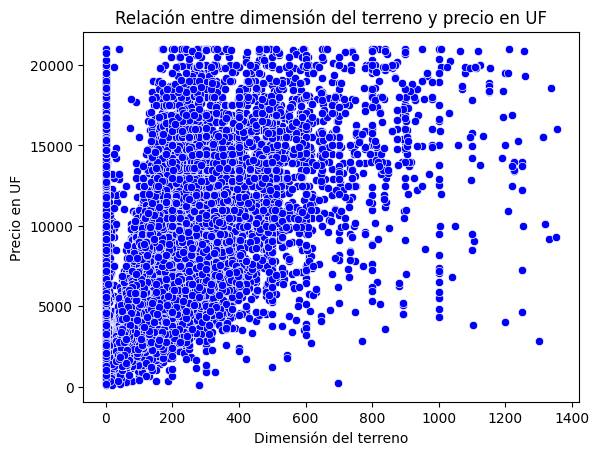

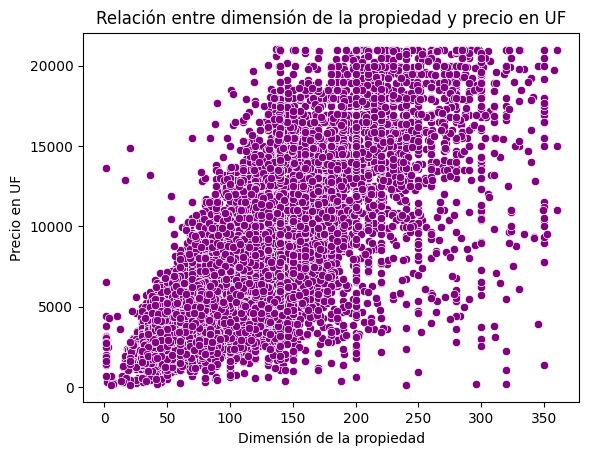

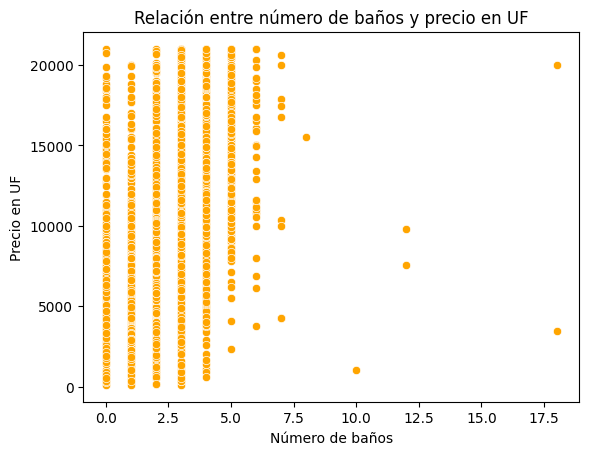

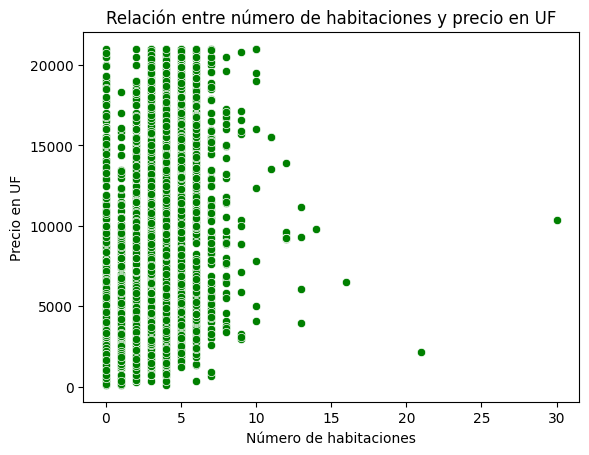

In [10]:
sns.scatterplot(x="dimension_terreno", y="precio_en_uf", data=df, color = "blue")
plt.xlabel("Dimensión del terreno") 
plt.ylabel("Precio en UF")
plt.title("Relación entre dimensión del terreno y precio en UF")
plt.show()

sns.scatterplot(x="dimension_propiedad", y="precio_en_uf", data=df, color = "purple")
plt.xlabel("Dimensión de la propiedad")
plt.ylabel("Precio en UF")
plt.title("Relación entre dimensión de la propiedad y precio en UF")

plt.show()


sns.scatterplot(x="banos", y="precio_en_uf", data=df, color = "orange")
plt.xlabel("Número de baños")
plt.ylabel("Precio en UF")
plt.title("Relación entre número de baños y precio en UF")
plt.show()

sns.scatterplot(x="habitaciones", y="precio_en_uf", data=df, color = "green")
plt.xlabel("Número de habitaciones")
plt.ylabel("Precio en UF")
plt.title("Relación entre número de habitaciones y precio en UF")
plt.show()



Para poder calcular la correlación entre las variables numericas utilizaremos el metodo `corr` de pandas. Sin embargo, hay que tener en consideracion que algunas variables a pesar de ser de algun tipo numerico, son variables categoricas, como por ejemplo `piso` que se refiere a que piso se encuentra la propiedad. Por lo tanto, se deben considerar solo las siguientes varibles numericas: `precio_en_uf`, `dimension_terreno`, `dimension_propiedad`, `banos`, `habitaciones`, `estacionamientos`, `cantidad_caracteristicas` y `gastos_comunes`.

Se puede observar que la variable con mayor correlacion con el `precio_en_uf` es la `dimension_propiedad`. Esto se debe a que a medida que aumenta la dimension de la propiedad, el precio en uf tiende a aumentar. La dimension de la propiedad tambíen esta altamente correlacionada con la dimension del terreno, lo que puede significar que estas variables estan relacionadas entre si, ya que a mayor terreno, mayor dimension de la propiedad. En cuanto a las otras variables, se puede observar que tienen una correlacion baja entre si, superando un valor aproximadamente de 0.5 entre ellas. Esto se puede deber a que existen propiedades con poco baños o habitaciones por ejemplo, pero con un gran precio. 

A partir de esto, podemos ver que las variables más relacionadas entre si son `precio_en_uf`, `dimension_propiedad`, `dimension_terreno`, `banos` y `habitaciones`. Por lo tanto, a partir de esta información y de la mencionada anteriormente, se puede concluir que las variables `dimension_propiedad`, `dimension_terreno`, `banos` y `habitaciones` (a pesar que vimos que las ultimas dos, no son tan relevantes debido a que existen muchas propiedades con precios altos y poco baños por ejemplo, o propiedades con precios bajos y muchos baños) son las mejores variables para predecir el precio en uf. Y dentro de estas, el mejor predictor del precio en uf, es `dimension_priopuedad`. 

In [11]:
correlacion = df[["precio_en_uf", "dimension_terreno", "dimension_propiedad", "banos", "habitaciones", "estacionamientos", "cantidad_caracteristicas", "gastos_comunes"]].corr()

print(correlacion)



                          precio_en_uf  dimension_terreno  \
precio_en_uf                  1.000000           0.601295   
dimension_terreno             0.601295           1.000000   
dimension_propiedad           0.800352           0.704111   
banos                         0.642795           0.510706   
habitaciones                  0.465077           0.508174   
estacionamientos             -0.001751          -0.003018   
cantidad_caracteristicas     -0.035228          -0.015945   
gastos_comunes               -0.008700          -0.007553   

                          dimension_propiedad     banos  habitaciones  \
precio_en_uf                         0.800352  0.642795      0.465077   
dimension_terreno                    0.704111  0.510706      0.508174   
dimension_propiedad                  1.000000  0.690453      0.651999   
banos                                0.690453  1.000000      0.613558   
habitaciones                         0.651999  0.613558      1.000000   
estacionamie

<Axes: >

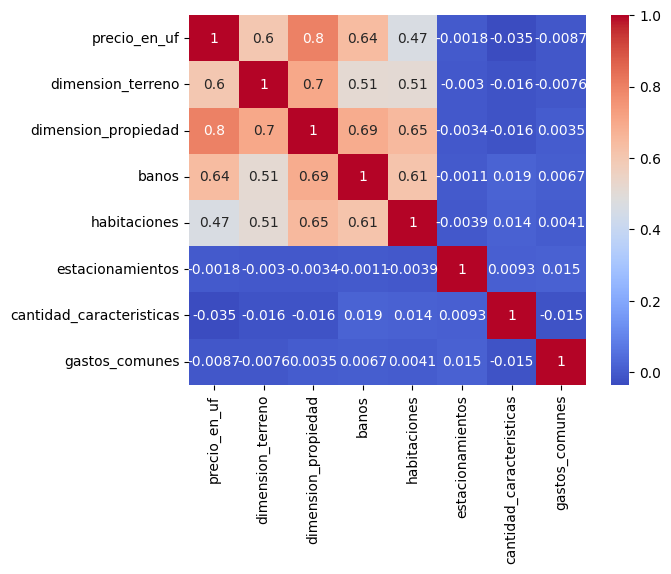

In [12]:
sns.heatmap(correlacion, annot=True, cmap="coolwarm")

Veremos si existe correlacion entre las otras variables categoricas mencionadas anteriormente (`"precio_en_uf", "id_tipo_propiedad", "id_comuna", "id_provincia", "id_region", "id_antiguedad", "year" `)


Se puede observar que no hay una correlacion clara entre estas variables y el precio, lo que implica que estas variables no son buenos predictores del precio en uf.

<Axes: >

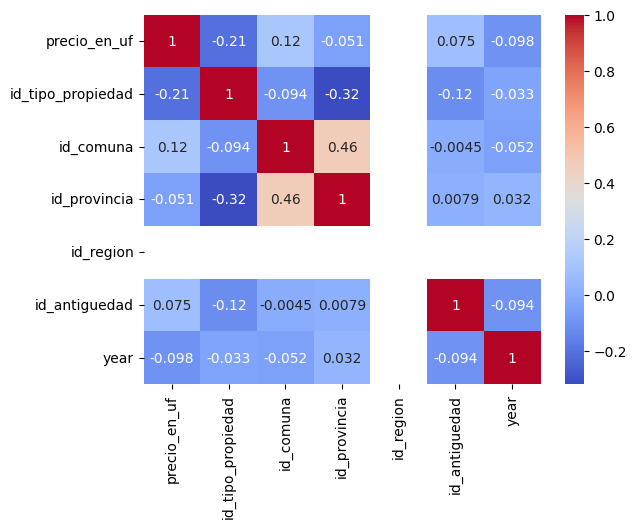

In [13]:
correlacion_categorica = df[["precio_en_uf", "id_tipo_propiedad", "id_comuna", "id_provincia", "id_region", "id_antiguedad", "year"]].corr()

sns.heatmap(correlacion_categorica, annot=True, cmap="coolwarm")

Viendo nuevamente en un mapa de calor todas las variables numericas, observemos que más alla de lo descrito, no hay una relacion clara entre si.

<Axes: >

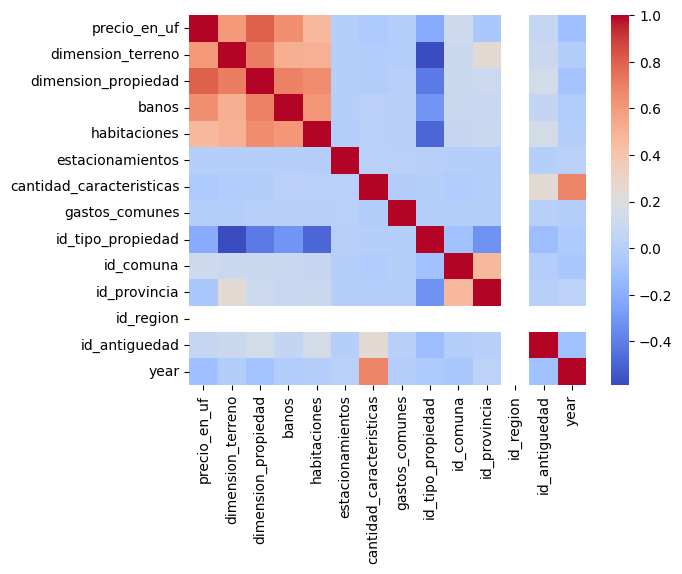

In [14]:
correlacion_final = df[["precio_en_uf", "dimension_terreno", "dimension_propiedad", "banos", "habitaciones", "estacionamientos", "cantidad_caracteristicas", "gastos_comunes", "id_tipo_propiedad", "id_comuna", "id_provincia", "id_region", "id_antiguedad", "year"]].corr()

sns.heatmap(correlacion_final, annot=False, cmap="coolwarm")

Es poner importante incapie que hay variables con valores anormales, por ejemplo, la variable `year` posee valores 0, lo que no posee sentido. Otro ejemplo seria lo valores `null` en formato string lo que no es un valor nulo real. Estos valores anormales pueden afectar mucho a los modelos, ya que no pueden ser capaces de reconocer patrones en los datos, lo que puede llevar a un bajo rendimiento. Por lo tanto, es importante limpiar los datos y eliminar estos valores anormales para mejorar el rendimiento de los modelos.

# *Parte 2.3.2.*

Empezaremos analizando el rol de las variables y que hacer con ellas

- `descripcion` e `id`: Esta variable es de tipo string, y cada propiedad tiene una descripción unica por ende no es una variable util para predecir el precio, por lo tanto, se puede eliminar esta variable del df. Posee una baja correlacion con el precio.

- `direccion` y `direccion_2`: Similar a lo anterior, esta variable es una variable string y cada propiedad posee una dirección unica, por lo tanto, no es una variable util para predecir, porque además, la ubicación de la propiedad ya esta representada por las variables `id_comuna`, `id_provincia` e `id_region` que entrega información mucho más general sobre la ubicación de la propiedad, lo que puede ayudar a generalizar el precio de la propiedad segun su ubicación, por lo tanto, se pueden eliminar estas variables del df. Y notese que esta variable presenta a las comunas como un str en vez de un int. Posee una baja correlacion con el precio.



In [15]:
print(df["direccion_2"])

0        Vitacura                                      ...
1        Macul                                         ...
2        La Reina                                      ...
3        ÑUÑOA                                         ...
4        Vitacura                                      ...
                               ...                        
20891                                                  NaN
20892    Las Condes                                    ...
20893    Til Til                                       ...
20894    Las Condes                                    ...
20895                                                  NaN
Name: direccion_2, Length: 20264, dtype: object


In [16]:

df_limpio = df.copy()
df_limpio = df_limpio.drop(columns=["id", "descripcion", "direccion", "direccion_2"])

print(df_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_tipo_propiedad         20264 non-null  int64  
 1   habitaciones              20264 non-null  int64  
 2   banos                     20264 non-null  int64  
 3   dimension_propiedad       20264 non-null  float64
 4   dimension_terreno         20264 non-null  float64
 5   id_comuna                 20264 non-null  int64  
 6   id_provincia              20151 non-null  Int64  
 7   id_region                 20264 non-null  int64  
 8   id_antiguedad             20264 non-null  int64  
 9   year                      15847 non-null  Int64  
 10  gastos_comunes            16033 non-null  float64
 11  piso                      5842 non-null   Int64  
 12  estacionamientos          18091 non-null  Int64  
 13  amoblado                  18005 non-null  object 
 14  cantidad_ca

- `id_region`: esta variable es una variable categorica que representa la region donde se encuentra la propiedad através de un id int. Pero notemos que esta variable solo posee 1 valor unico, lo que implica que todas las propiedades se encuentran en la misma region, por lo tanto, esta variable no aporta información relevante para predecir el precio, ya que no hay variabilidad en esta variable, por lo tanto, se puede eliminar esta variable del df.
Posee una baja correlacion con el precio.

In [17]:
print(df["id_region"].value_counts())

df_limpio = df_limpio.drop(columns=["id_region"])


id_region
13    20264
Name: count, dtype: int64


In [18]:
print(df_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_tipo_propiedad         20264 non-null  int64  
 1   habitaciones              20264 non-null  int64  
 2   banos                     20264 non-null  int64  
 3   dimension_propiedad       20264 non-null  float64
 4   dimension_terreno         20264 non-null  float64
 5   id_comuna                 20264 non-null  int64  
 6   id_provincia              20151 non-null  Int64  
 7   id_antiguedad             20264 non-null  int64  
 8   year                      15847 non-null  Int64  
 9   gastos_comunes            16033 non-null  float64
 10  piso                      5842 non-null   Int64  
 11  estacionamientos          18091 non-null  Int64  
 12  amoblado                  18005 non-null  object 
 13  cantidad_caracteristicas  9164 non-null   float64
 14  precio_en_u

- `id_provincia`: esta variable es una variable categoria que representa la provincia a través de un id int. Sin embargo, esta variable presenta valores nulos y además, ya tenemos información más específica sobre la ubicación de la propiedad a través de la variable `id_comuna`, por lo tanto, esta variable no aporta información relevante para predecir el precio, ya que no hay variabilidad en esta variable, por lo tanto, se puede eliminar esta variable del df. Posee una baja correlacion con el precio.


In [19]:
df_limpio = df_limpio.drop(columns=["id_provincia"])
print(df_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_tipo_propiedad         20264 non-null  int64  
 1   habitaciones              20264 non-null  int64  
 2   banos                     20264 non-null  int64  
 3   dimension_propiedad       20264 non-null  float64
 4   dimension_terreno         20264 non-null  float64
 5   id_comuna                 20264 non-null  int64  
 6   id_antiguedad             20264 non-null  int64  
 7   year                      15847 non-null  Int64  
 8   gastos_comunes            16033 non-null  float64
 9   piso                      5842 non-null   Int64  
 10  estacionamientos          18091 non-null  Int64  
 11  amoblado                  18005 non-null  object 
 12  cantidad_caracteristicas  9164 non-null   float64
 13  precio_en_uf              20264 non-null  float64
dtypes: Int64(3)

- `year`: como se menciono anteriormente, esta variable posee valores anormales como el valor 0, la cual no posee sentido y además ocupa más de 10.000 espacios de la base de datos, lo que implica que esta variable no aporta información relevante para predecir el precio y además no se puede hacer inputing de esta variable debido a la gran cantidad de valores anormales, por lo tanto, se puede eliminar esta variable del df. Además poseemos la variable `id_antiguedad` que representa la antiguedad de la propiedad, lo que puede ser una mejor manera de representar la antiguedad.

In [20]:
print(df["year"].value_counts())


year
0       11306
2015      267
2014      245
2016      231
2017      217
        ...  
74          1
25          1
1860        1
91          1
1014        1
Name: count, Length: 137, dtype: Int64


In [21]:
df_limpio = df_limpio.drop(columns=["year"])
print(df_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_tipo_propiedad         20264 non-null  int64  
 1   habitaciones              20264 non-null  int64  
 2   banos                     20264 non-null  int64  
 3   dimension_propiedad       20264 non-null  float64
 4   dimension_terreno         20264 non-null  float64
 5   id_comuna                 20264 non-null  int64  
 6   id_antiguedad             20264 non-null  int64  
 7   gastos_comunes            16033 non-null  float64
 8   piso                      5842 non-null   Int64  
 9   estacionamientos          18091 non-null  Int64  
 10  amoblado                  18005 non-null  object 
 11  cantidad_caracteristicas  9164 non-null   float64
 12  precio_en_uf              20264 non-null  float64
dtypes: Int64(2), float64(5), int64(5), object(1)
memory usage: 2.2+ MB

- `piso` `cantidad_caracteristicas`: Similar a lo anterior, posee demasiados valores nulos que no es recomendable hacer imputing, y además, no es una variable relevante para predecir el precio.

In [22]:
df_limpio = df_limpio.drop(columns=["piso", "cantidad_caracteristicas"])
print(df_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_tipo_propiedad    20264 non-null  int64  
 1   habitaciones         20264 non-null  int64  
 2   banos                20264 non-null  int64  
 3   dimension_propiedad  20264 non-null  float64
 4   dimension_terreno    20264 non-null  float64
 5   id_comuna            20264 non-null  int64  
 6   id_antiguedad        20264 non-null  int64  
 7   gastos_comunes       16033 non-null  float64
 8   estacionamientos     18091 non-null  Int64  
 9   amoblado             18005 non-null  object 
 10  precio_en_uf         20264 non-null  float64
dtypes: Int64(1), float64(4), int64(5), object(1)
memory usage: 1.9+ MB
None


- `id_tipo_propiedad`: Como solo posee 3 valores, podemos hacer one hot encoding para convertir esta variable en tres variables binarias. Esto porque en label encoding se le asignaria un orden especifico a cada tipo de propiedad, pero no posee sentido ya que no sabemos cuales son los tipos de propiedad que existen, por lo tanto, no se puede asignar un orden a estas variables, por lo tanto, es mejor hacer one hot encoding para evitar este problema. Posee una baja correlacion con el precio.

In [23]:
df["id_tipo_propiedad"].value_counts()

id_tipo_propiedad
2    12618
1     6981
3      665
Name: count, dtype: int64

In [24]:
df_limpio = pd.get_dummies(df_limpio, columns=["id_tipo_propiedad"])

In [25]:
print(df_limpio.info())
print(df_limpio["id_tipo_propiedad_1"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   habitaciones         20264 non-null  int64  
 1   banos                20264 non-null  int64  
 2   dimension_propiedad  20264 non-null  float64
 3   dimension_terreno    20264 non-null  float64
 4   id_comuna            20264 non-null  int64  
 5   id_antiguedad        20264 non-null  int64  
 6   gastos_comunes       16033 non-null  float64
 7   estacionamientos     18091 non-null  Int64  
 8   amoblado             18005 non-null  object 
 9   precio_en_uf         20264 non-null  float64
 10  id_tipo_propiedad_1  20264 non-null  bool   
 11  id_tipo_propiedad_2  20264 non-null  bool   
 12  id_tipo_propiedad_3  20264 non-null  bool   
dtypes: Int64(1), bool(3), float64(4), int64(4), object(1)
memory usage: 1.8+ MB
None
id_tipo_propiedad_1
False    13283
True      6981
Name: coun

- `amoblado`: Es una variable catogorica que representa si la propiedad esta amoblada o no a través de booleano. No posee demasiados valores nulos, por lo tanto se puede hacer imputing de la moda para rellenar los valores faltantes y luego hacer one hot enconding para convertir esta variable en dos variables binarias. Posee una baja correlacion con el precio.

In [26]:
df_limpio["amoblado"] = df_limpio["amoblado"].fillna(df_limpio['amoblado'].mode()[0])

print(df_limpio.info())     

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   habitaciones         20264 non-null  int64  
 1   banos                20264 non-null  int64  
 2   dimension_propiedad  20264 non-null  float64
 3   dimension_terreno    20264 non-null  float64
 4   id_comuna            20264 non-null  int64  
 5   id_antiguedad        20264 non-null  int64  
 6   gastos_comunes       16033 non-null  float64
 7   estacionamientos     18091 non-null  Int64  
 8   amoblado             20264 non-null  object 
 9   precio_en_uf         20264 non-null  float64
 10  id_tipo_propiedad_1  20264 non-null  bool   
 11  id_tipo_propiedad_2  20264 non-null  bool   
 12  id_tipo_propiedad_3  20264 non-null  bool   
dtypes: Int64(1), bool(3), float64(4), int64(4), object(1)
memory usage: 1.8+ MB
None


In [27]:
df_limpio = pd.get_dummies(df_limpio, columns=["amoblado"])

In [28]:
print(df_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   habitaciones         20264 non-null  int64  
 1   banos                20264 non-null  int64  
 2   dimension_propiedad  20264 non-null  float64
 3   dimension_terreno    20264 non-null  float64
 4   id_comuna            20264 non-null  int64  
 5   id_antiguedad        20264 non-null  int64  
 6   gastos_comunes       16033 non-null  float64
 7   estacionamientos     18091 non-null  Int64  
 8   precio_en_uf         20264 non-null  float64
 9   id_tipo_propiedad_1  20264 non-null  bool   
 10  id_tipo_propiedad_2  20264 non-null  bool   
 11  id_tipo_propiedad_3  20264 non-null  bool   
 12  amoblado_f           20264 non-null  bool   
 13  amoblado_t           20264 non-null  bool   
dtypes: Int64(1), bool(5), float64(4), int64(4)
memory usage: 1.7 MB
None


- `gastos_comunes`: Esta es una desición más compleja, pero debido a la gran cantidad de valores nulos, y a que esta variable no es tan relevante para predecir el precio, se puede eliminar esta variable del df. Posee una baja correlacion con el precio. Principalmente esto se hara porque esta variable posee una mediana igual a 0, lo que implica que la mitad de los datos son 0, lo que puede ser un valor anormal, y además, esta variable no es tan relevante para predecir el precio, por lo tanto, se puede eliminar esta variable del df.

In [29]:
print(df_limpio["gastos_comunes"].median())

df_limpio = df_limpio.drop(columns=["gastos_comunes"])
print(df_limpio.info())

0.0
<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   habitaciones         20264 non-null  int64  
 1   banos                20264 non-null  int64  
 2   dimension_propiedad  20264 non-null  float64
 3   dimension_terreno    20264 non-null  float64
 4   id_comuna            20264 non-null  int64  
 5   id_antiguedad        20264 non-null  int64  
 6   estacionamientos     18091 non-null  Int64  
 7   precio_en_uf         20264 non-null  float64
 8   id_tipo_propiedad_1  20264 non-null  bool   
 9   id_tipo_propiedad_2  20264 non-null  bool   
 10  id_tipo_propiedad_3  20264 non-null  bool   
 11  amoblado_f           20264 non-null  bool   
 12  amoblado_t           20264 non-null  bool   
dtypes: Int64(1), bool(5), float64(3), int64(4)
memory usage: 1.5 MB
None


- `estacionamientos`: Esta variable a pesar de que no este tan correlacionada con el precio, es una variable que no posee tantos valores nulos como para elimminarla, por lo tanto, se puede hacer imputing de la mediana para rellenar los valores faltantes. Posee una baja correlacion con el precio. 

In [30]:
estacionamientos_counts = df_limpio["estacionamientos"].value_counts()
#print(estacionamientos_counts)
#print(df["precio_en_uf"][df["estacionamientos"]== 130000])
df_limpio["estacionamientos"] = df_limpio["estacionamientos"].fillna(df_limpio["estacionamientos"].median())
print(df_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20264 entries, 0 to 20895
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   habitaciones         20264 non-null  int64  
 1   banos                20264 non-null  int64  
 2   dimension_propiedad  20264 non-null  float64
 3   dimension_terreno    20264 non-null  float64
 4   id_comuna            20264 non-null  int64  
 5   id_antiguedad        20264 non-null  int64  
 6   estacionamientos     20264 non-null  Int64  
 7   precio_en_uf         20264 non-null  float64
 8   id_tipo_propiedad_1  20264 non-null  bool   
 9   id_tipo_propiedad_2  20264 non-null  bool   
 10  id_tipo_propiedad_3  20264 non-null  bool   
 11  amoblado_f           20264 non-null  bool   
 12  amoblado_t           20264 non-null  bool   
dtypes: Int64(1), bool(5), float64(3), int64(4)
memory usage: 1.5 MB
None


# *2.3.3 División De Datos*

Ocuparemos la función `train_test_split` de sklearn para dividir los datos en entrenamiento, validación y prueba. Dividiremos los datos de entrenamiento  y prueba con test.size=0.3, lo que implica que el 30% de los datos se utilizaran para prueba y el 70% para entrenamiento. 

Luego los datos de prueba los dividiremos nuevamente en prueba y validación con test.size = 0.5, lo que implica que el 15% de los datos seran para validación. 

Queremos estos porcentajes para tener una buena cantidad de datos para entrenar el modelo, pero a la vez, tener suficientes datos para probar y validar el modelo.

Estos porcentajes nos ayudaran a tener buena cantidad de datos para entrenar al modelo, pero a la vez, tener suficientes datos para probar y validar el modelo y predicir el precio de las propiedades.

In [31]:
len(df_limpio)
print(0.15 * len(df_limpio))
print(0.7 * len(df_limpio))

3039.6
14184.8


In [32]:
features = ["dimension_terreno", "dimension_propiedad", "banos", "habitaciones", "estacionamientos", "id_comuna", "id_antiguedad", "id_tipo_propiedad_1", "id_tipo_propiedad_2", "id_tipo_propiedad_3", "amoblado_f", "amoblado_t"]

target = "precio_en_uf"

In [33]:
# matriz de features

x = df_limpio[features]
y = df_limpio[target]


In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [35]:
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

In [36]:
x_train.head()

,dimension_terreno,dimension_propiedad,banos,habitaciones,estacionamientos,id_comuna,id_antiguedad,id_tipo_propiedad_1,id_tipo_propiedad_2,id_tipo_propiedad_3,amoblado_f,amoblado_t
13342,430.0,110.0,1,4,4,277,2,True,False,False,True,False
13338,335.0,163.0,3,3,2,287,2,True,False,False,True,False
12229,180.0,160.0,4,3,2,288,2,False,True,False,True,False
7868,110.0,90.0,2,2,2,288,2,False,True,False,True,False
11352,86.0,86.0,2,3,1,288,2,False,True,False,True,False


# Parte 2.3.5 y 2.3.6


## Modelo De Regresión Lineal

La regresión lineal es un modelo que se utiliza para predecir una variable continua a partir de otras independientes, en este caso queremos predecir el precio de las propiedades.

El modelo asume que existe una relación lineal entre las variables y la variable objetivo, lo que implica que el precio de las propiedades se puede predecir con un combinación lineal de las variables.  Por lo que, si no existe una relacion claramente lineal, puede haber serios problemas de rendimiento. El modelo capta variables que tienen una relacion lineal con el precio.

In [37]:
modelo = LinearRegression()

modelo.fit(x_train, y_train)


#validación
y_pred_val = modelo.predict(x_val)

y_pred = modelo.predict(x_test)


In [38]:
pd.DataFrame({"y_val": y_val, "y_pred_val": y_pred_val})

,y_val,y_pred_val
4151,7750.000000,6999.080696
4740,6275.000000,7869.196298
15202,3143.899227,5000.300808
14739,9538.780181,8768.524026
17274,1550.000000,2835.231575
...,...,...
4604,1409.135425,3610.715555
19719,3514.000000,4774.524351
16731,3003.306764,5143.566456
7121,8551.596669,6636.892775


In [39]:
mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)
rmse = np.sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")

MAE: 1810.5059235894694
MSE: 6582694.356894481
R2: 0.6853801640025367
RMSE: 2565.6761987621276


In [40]:
pd.DataFrame({"y_test": y_test, "y_pred": y_pred})


,y_test,y_pred
1777,8900.0,9053.659489
10826,10950.0,11297.869942
20100,4900.0,5765.176346
18576,4655.0,6131.587426
11641,10420.0,16156.072532
...,...,...
15596,3200.0,4180.372953
20725,4500.0,5935.342645
6880,8900.0,6842.878241
8103,15500.0,19600.126823


Se puede observar que el modelo tiene un rendimiento bajo, y por el hecho de que no existe una relacion claramente lineal entre las variables y el precio, lo que implica que este modelo no es el mejor para predecir el precio de las propiedades.

In [41]:
y_pred_train = modelo.predict(x_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
print(f"MAE (Entrenamiento): {mae_train}")
print(f"R2 (Entrenamiento): {r2_train}")

MAE (Entrenamiento): 1750.2058492062692
R2 (Entrenamiento): 0.7076472989578123


In [42]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")


MAE: 1763.8742683741675
MSE: 5787512.224294623
R2: 0.7247486758610071
RMSE: 2405.72488541284


## Arbol de Regresión

Para este modelo es importante ajustar el hiperparametro de la profundidad del arbol, y que esto puede afectar el rendimiento del modelo. Por lo tanto, se entrenara el modelo con una profundidad en especifico y luego se evaluara con los datos de validación para ver el rendimiento del modelo, y asi poder ajustar la profundidad del arbol para obtener un mejor rendimiento. Se entrenara el modelo con una profundidad de 3, lo que implica que el arbol tendra una profundidad de 3 niveles.

Un arbol de regresion es un tipo de arbol de desición que se utiliza para predecir valores numericos continuos. El arbol utiliza reglas para dividir los datos y luego hace predicciones basadas en estas reglas. El modelo de arbol es capaz de captar relaciones no lineales. Sin embargo, este modelo puede tener serios problemas de complejidad y sobreajuste, lo que puede llevar una mala generalización. Los supuestos que tiene este modelo es que se puede dividir los datos utilizando reglas. 
(Scikit-learn, s.f.)


In [43]:
modelo_arbol = DecisionTreeRegressor(max_depth = 3, random_state=42)
modelo_arbol.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [44]:
y_pred_val_arbol = modelo_arbol.predict(x_val)

In [45]:
pd.DataFrame({"y_val": y_val, "y_pred_val": y_pred_val_arbol})

,y_val,y_pred_val
4151,7750.000000,6639.529138
4740,6275.000000,6639.529138
15202,3143.899227,4837.537470
14739,9538.780181,10498.256309
17274,1550.000000,2798.775739
...,...,...
4604,1409.135425,2798.775739
19719,3514.000000,4114.360167
16731,3003.306764,4114.360167
7121,8551.596669,6639.529138


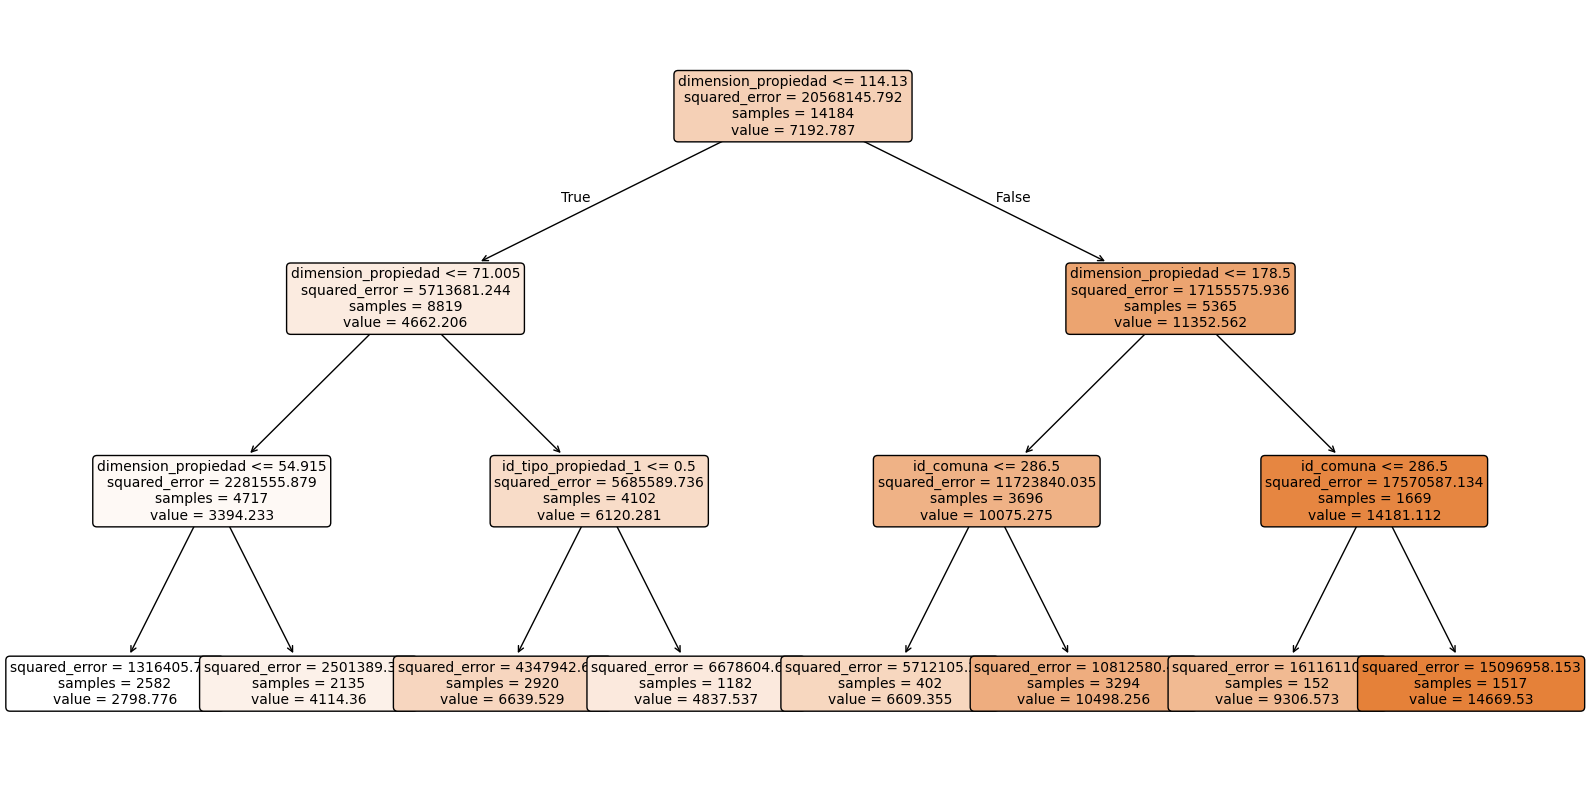

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(modelo_arbol, 
          feature_names=features, 
          filled=True,                  
          rounded=True,                  
          fontsize=10)
plt.show()


In [47]:
r2_arbol_val = r2_score(y_val, y_pred_val_arbol)
mae_arbol_val = mean_absolute_error(y_val, y_pred_val_arbol)
print(f"R2 del árbol de decisión: {r2_arbol_val}")
print(f"MAE del árbol de decisión: {mae_arbol_val}")


R2 del árbol de decisión: 0.6776578305865524
MAE del árbol de decisión: 1882.3331966459782


In [48]:
y_pred_train = modelo_arbol.predict(x_train)
r2_train = r2_score(y_train, y_pred_train)
mae_arbol_train = mean_absolute_error(y_train, y_pred_train)
print(f"R2 en el conjunto de entrenamiento: {r2_train}")
print(f"MAE en el conjunto de entrenamiento: {mae_arbol_train}")

R2 en el conjunto de entrenamiento: 0.6826125295659184
MAE en el conjunto de entrenamiento: 1842.21565197491



 Ahora analizaremos que ocurre cuando se ajusta la profundidad del arbol. Para esto graficaremos. Se puede observar que a medida que aumenta la profundidad del arbol, el rendimiento del modelo en el conjunto de validación aumenta, pero a partir de cierta profundidad, el rendimiento del modelo en el conjunto de validación disminuye, lo que implica que el modelo esta aprendiendo de memoria los datos y no esta generalizando bien, lo que seria overfitting, por lo tanto, es importante ajustar la profundidad del arbol para evitar este problema y obtener un mejor rendimiento en el conjunto de validación. A valores menores que 10 el modelo no presenta overfitting, pero a partir de 10, el modelo comienza a presentar overfitting, lo que implica que el modelo esta aprendiendo de memoria los datos y no esta generalizando bien, por lo tanto, es importante ajustar la profundidad del arbol para evitar este problema y obtener un mejor rendimiento en el conjunto de validación. (Pontificia Universidad Católica de Chile, s.f.)

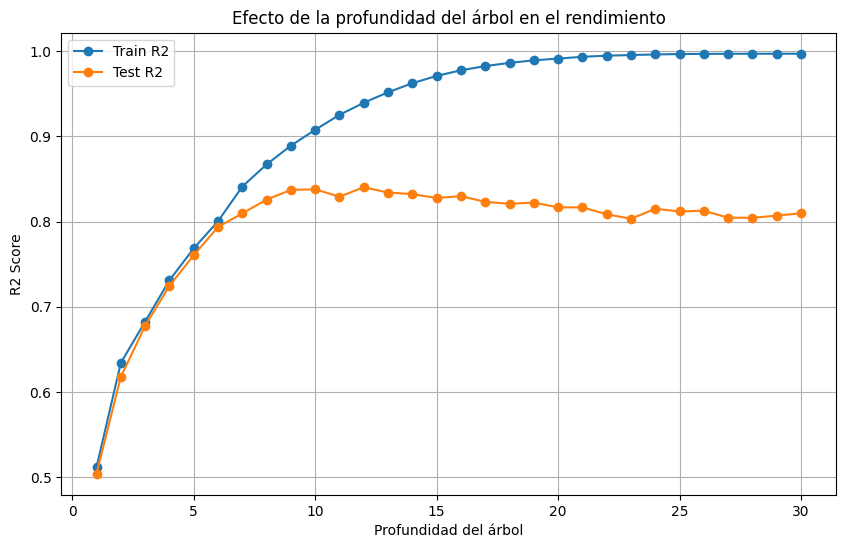

In [49]:
def analizar_profundidad_regresion(X_train, X_val, y_train, y_val, max_depth=30):
    depths = range(1, max_depth + 1)
    train_r2 = []
    test_r2 = []

    for d in depths:
        
        model = DecisionTreeRegressor(max_depth=d, random_state=42)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        #cambiamos en vez de acuracy enseñado en la ayudantia, por R2 Score
        train_r2.append(r2_score(y_train, y_train_pred))
        test_r2.append(r2_score(y_val, y_val_pred))


    plt.figure(figsize=(10, 6))
    plt.plot(depths, train_r2, label="Train R2", marker='o')
    plt.plot(depths, test_r2, label="Test R2", marker='o')
    plt.xlabel("Profundidad del árbol")
    plt.ylabel("R2 Score")
    plt.title("Efecto de la profundidad del árbol en el rendimiento")
    plt.legend()
    plt.grid(True)
    plt.show()


analizar_profundidad_regresion(x_train, x_val, y_train, y_val)

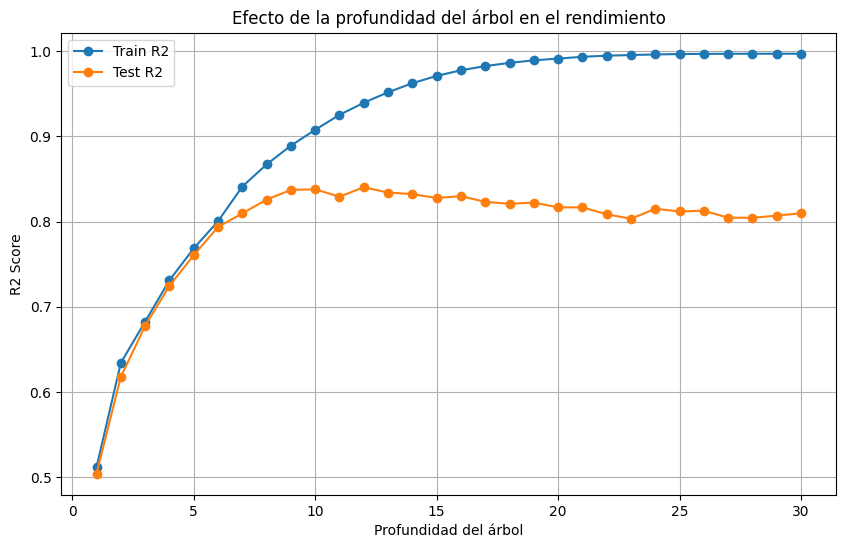

In [50]:
analizar_profundidad_regresion(x_train, x_val, y_train, y_val)

En este caso, se decidira ajustar la profundidad del arbol a 6, ya que presenta un buen rendimiento en el conjunto de validación sin presentar overfitting, lo que implica que el modelo esta generalizando bien. 

In [51]:
modelo_arbol = DecisionTreeRegressor(max_depth=6, random_state=42)
modelo_arbol.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [52]:
y_pred_test_arbol = modelo_arbol.predict(x_test)

In [53]:
pd.DataFrame({"y_test": y_test, "y_pred_test": y_pred_test_arbol})

,y_test,y_pred_test
1777,8900.0,8981.118761
10826,10950.0,11365.627149
20100,4900.0,5888.447241
18576,4655.0,8382.700704
11641,10420.0,12919.827284
...,...,...
15596,3200.0,2824.657404
20725,4500.0,4262.084606
6880,8900.0,7505.126964
8103,15500.0,14483.276061


In [54]:
y_pred_train = modelo_arbol.predict(x_train)
r2_train = r2_score(y_train, y_pred_train)
mae_arbol_train = mean_absolute_error(y_train, y_pred_train)
print(f"R2 en el conjunto de entrenamiento: {r2_train}")
print(f"MAE en el conjunto de entrenamiento: {mae_arbol_train}")

R2 en el conjunto de entrenamiento: 0.8001772607506425
MAE en el conjunto de entrenamiento: 1373.035921523588


In [55]:
y_pred_val = modelo_arbol.predict(x_val)
r2_val = r2_score(y_val, y_pred_val)
mae_arbol_val = mean_absolute_error(y_val, y_pred_val)
print(f"R2 en el conjunto de validación: {r2_val}")
print(f"MAE en el conjunto de validación: {mae_arbol_val}")

R2 en el conjunto de validación: 0.7935238843577487
MAE en el conjunto de validación: 1421.2426135554972


Se puede observar que el modelo difiere menos de 0.02 en r2_score entre el conjunto de test y el conjunto de entrenamiento, lo que implica que el modelo esta generalizando bien y no esta presentando overfitting, lo que es un buen resultado. Aumentaremos nuevamente la profundidad del arbol a 8 para ver si el modelo presenta overfitting o no, y si mejora el redimiento del modelo.

In [56]:
modelo_arbol = DecisionTreeRegressor(max_depth=8, random_state=42)
modelo_arbol.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [57]:
y_pred_test_arbol = modelo_arbol.predict(x_test)

In [58]:
pd.DataFrame({"y_test": y_test, "y_pred_test": y_pred_test_arbol})

,y_test,y_pred_test
1777,8900.0,10706.144537
10826,10950.0,11234.143335
20100,4900.0,5888.004777
18576,4655.0,5666.944475
11641,10420.0,9606.646075
...,...,...
15596,3200.0,2854.159326
20725,4500.0,3806.382869
6880,8900.0,7697.924103
8103,15500.0,15894.599865


In [59]:
y_pred_train = modelo_arbol.predict(x_train)
r2_train = r2_score(y_train, y_pred_train)
mae_arbol_train = mean_absolute_error(y_train, y_pred_train)
print(f"R2 en el conjunto de entrenamiento: {r2_train}")
print(f"MAE en el conjunto de entrenamiento: {mae_arbol_train}")

R2 en el conjunto de entrenamiento: 0.8669054604351524
MAE en el conjunto de entrenamiento: 1115.3008810345518


In [60]:
y_pred_val_arbol = modelo_arbol.predict(x_val)
r2_val = r2_score(y_val, y_pred_val_arbol)
mae_arbol_val = mean_absolute_error(y_val, y_pred_val_arbol)
print(f"R2 en el conjunto de validación: {r2_val}")
print(f"MAE en el conjunto de validación: {mae_arbol_val}")


R2 en el conjunto de validación: 0.8256495316476675
MAE en el conjunto de validación: 1256.7634586315153


In [61]:
r2_test_arbol = r2_score(y_test, y_pred_test_arbol)
mae_test_arbol = mean_absolute_error(y_test, y_pred_test_arbol)
print(f"R2 en el conjunto de prueba: {r2_test_arbol}")
print(f"MAE en el conjunto de prueba: {mae_test_arbol}")

R2 en el conjunto de prueba: 0.8395363694423617
MAE en el conjunto de prueba: 1226.3609094884735


Se puede observar que el modelo de arbol funciona mucho mejor que el modelo de regresion lineal, lo que se puede deber a que el modelo de regresion lineal asume que existe una relacion lineal entre las variables y la variable objetivo, lo que no es el caso en este dataset, ya que existen relaciones no lineales entre las variables y la variable objetivo, lo que implica que el modelo de regresion lineal no es capaz de capturar estas relaciones, mientras que el modelo de arbol de regresion si es capaz de capturar estas relaciones no lineales, lo que explica su mejor rendimiento.

`Expliques brevemente el funcionamiento del modelo, destacando sus principales supuestos y carac-terísticas.Comentes, de forma preliminar, qué tipo de relaciones es capaz de capturar (lineales, no lineales,interacciones, etc.)`

# Random Forest 
Ocuparemos el modelo de Random Forest para ver si podemos mejorar el rendimiento. Este modelo es un modelo de ensamble que se basa en combinar varios arboles de regresion para obtener una mejor funcionalidad y rendimiento.

El modelo de random forest es capaz de capturar relaciones no lineales entre las variables y la variable objetivo. Este modelo es menos propenso a presentar sobreajuste ya que utiliza varios árboles de regresión para hacer la predicción. La ` idea central del modelo ` es reducir la varianza del modelo de un simple arbol de regresion, utilizando varios arboles. (Scikit-learn, s.f.)

In [62]:
modelo_forest = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

In [63]:
modelo_forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [64]:
y_pred_val_forest = modelo_forest.predict(x_val)

In [65]:
pd.DataFrame({"y_val": y_val, "y_pred_val_forest": y_pred_val_forest})

,y_val,y_pred_val_forest
4151,7750.000000,6533.489520
4740,6275.000000,8927.000773
15202,3143.899227,4988.223794
14739,9538.780181,9389.809370
17274,1550.000000,2125.354233
...,...,...
4604,1409.135425,3482.073301
19719,3514.000000,4332.855738
16731,3003.306764,3333.933639
7121,8551.596669,6576.297818


In [66]:
y_pred_train_forest = modelo_forest.predict(x_train)
r2_train = r2_score(y_train, y_pred_train_forest)
mae_forest_train = mean_absolute_error(y_train, y_pred_train_forest)
print(f"R2 en el conjunto de entrenamiento: {r2_train}")
print(f"MAE en el conjunto de entrenamiento: {mae_forest_train}")

R2 en el conjunto de entrenamiento: 0.7898490410565939
MAE en el conjunto de entrenamiento: 1414.4982674149235


In [67]:
y_pred_val = modelo_forest.predict(x_val)
r2_val = r2_score(y_val, y_pred_val)
mae_forest_val = mean_absolute_error(y_val, y_pred_val)
print(f"R2 en el conjunto de validación: {r2_val}")
print(f"MAE en el conjunto de validación: {mae_forest_val}")

R2 en el conjunto de validación: 0.7800750624428565
MAE en el conjunto de validación: 1471.8523350519026


Observemos que los hiperparametros propuestos tienen un buen rendimiento en el conjunto de validación, lo que implica que el modelo esta generalizando bien y no esta presentando overfitting, lo que es un buen resultado. Similar al proceso anterior, graficaremos a ver que esta ocurriendo.

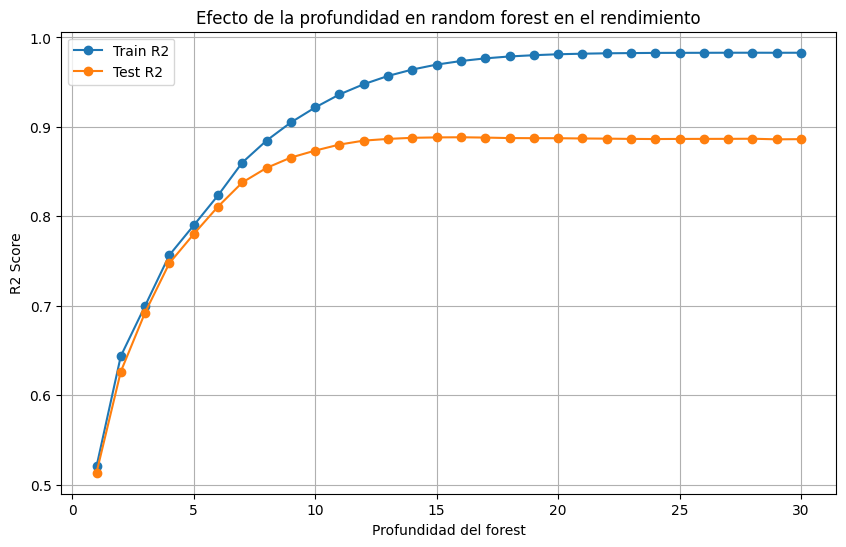

In [68]:
def analizar_profundidad_regresion_forest(X_train, X_val, y_train, y_val, max_depth=30):
    depths = range(1, max_depth + 1)
    train_r2 = []
    test_r2 = []

    for d in depths:
        
        model = RandomForestRegressor(max_depth=d, random_state=42)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        #cambiamos en vez de acuracy enseñado en la ayudantia, por R2 Score
        train_r2.append(r2_score(y_train, y_train_pred))
        test_r2.append(r2_score(y_val, y_val_pred))


    plt.figure(figsize=(10, 6))
    plt.plot(depths, train_r2, label="Train R2", marker='o')
    plt.plot(depths, test_r2, label="Test R2", marker='o')
    plt.xlabel("Profundidad del forest")
    plt.ylabel("R2 Score")
    plt.title("Efecto de la profundidad en random forest en el rendimiento")
    plt.legend()
    plt.grid(True)
    plt.show()

analizar_profundidad_regresion_forest(x_train, x_val, y_train, y_val)

Similar a lo anterior, se puede observar que a medida que aumenta la profundidad del arbol, el rendimiento del modelo en el conjunto de validación aumenta, pero a diferencia del modelo de arbol de regresion, el modelo de random forest no presenta una disminucion en el rendimiento del modelo, se estabiliza, lo que implica que el modelo de random forest es menos propenso a presentar overfitting que el modelo de arbol de regresion, lo que se debe a que este modelo ocupa varios arboles de regresion para hacer la prediccion. Por ende, llega un punto maximo y pero desde cierto punto, el modelo ya empieza a memorizar los datos (>15 aprox). 

In [69]:
modelo_forest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
modelo_forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [70]:
y_pred_val_forest = modelo_forest.predict(x_val)

In [71]:
pd.DataFrame({"y_val": y_val, "y_pred_val_forest": y_pred_val_forest})

,y_val,y_pred_val_forest
4151,7750.000000,7581.647198
4740,6275.000000,8634.322909
15202,3143.899227,4442.780208
14739,9538.780181,8739.096863
17274,1550.000000,1762.293556
...,...,...
4604,1409.135425,1913.011574
19719,3514.000000,3092.367483
16731,3003.306764,3434.844841
7121,8551.596669,6646.233726


In [72]:
y_pred_train_forest = modelo_forest.predict(x_train)
r2_train = r2_score(y_train, y_pred_train_forest)
mae_forest_train = mean_absolute_error(y_train, y_pred_train_forest)
print(f"R2 en el conjunto de entrenamiento: {r2_train}")
print(f"MAE en el conjunto de entrenamiento: {mae_forest_train}")

R2 en el conjunto de entrenamiento: 0.9216923145163415
MAE en el conjunto de entrenamiento: 857.4304986671427


In [73]:
y_pred_val_forest = modelo_forest.predict(x_val)
r2_val = r2_score(y_val, y_pred_val_forest)
mae_forest_val = mean_absolute_error(y_val, y_pred_val_forest)
print(f"R2 en el conjunto de validación: {r2_val}")
print(f"MAE en el conjunto de validación: {mae_forest_val}")

R2 en el conjunto de validación: 0.8734780095255037
MAE en el conjunto de validación: 1062.549630194082


Ahora veremos que ocurre con el hiperparametro `n_estimators`, que es la cantidad de arboles que se van a utilizar para hacer la prediccion. Se entrenara el modelo con una cantidad de arboles de 100, lo que implica que se van a utilizar 100 arboles de regresion para hacer la prediccion. 

*(importante: Se utilizo IA para modificar el codigo de la ayudantia para los n_estimators, se utilizo el siguiente prompt:)*

Como modifico este codigo, para implementarlo a un random forest, y que en vez del hiperparametro de profundidad, sea el hiperparametros de cantidad de arboles

```python
def analizar_profundidad_arbol(X_train, X_test, y_train, y_test, max_depth=30):

    depths = range(1, max_depth + 1)
    train_acc = []
    test_acc = []

    for d in depths:
        model = DecisionTreeClassifier(max_depth=d, random_state=42)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

    # gráfico
    plt.figure()
    plt.plot(depths, train_acc, label="Train Accuracy")
    plt.plot(depths, test_acc, label="Test Accuracy")
    plt.xlabel("Profundidad del árbol")
    plt.ylabel("Accuracy")
    plt.title("Efecto de la profundidad en overfitting")
    plt.legend()
    plt.grid()

    plt.show()

analizar_profundidad_arbol(X_train, X_test, y_train, y_test)


Me entrego la siguiente respuesta: 

Aquí tienes el código modificado para implementar un Random Forest y analizar el hiperparámetro n_estimators (cantidad de árboles).

He añadido un pequeño cambio práctico: un parámetro step en la función range(). Como entrenar un Random Forest toma más tiempo que un solo árbol de decisión, evaluar cada número del 1 al 100 uno por uno sería muy lento. Con step=5, el bucle saltará de 5 en 5 (1, 6, 11, 16...), ahorrándote mucho tiempo de ejecución sin perder el panorama general del gráfico.

```python
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def analizar_arboles_rf(X_train, X_test, y_train, y_test, max_trees=100, step=5):
    
    # Rango de árboles a evaluar, saltando según el valor de 'step'
    estimators = range(1, max_trees + 1, step)
    train_acc = []
    test_acc = []

    for n in estimators:
        # Usamos RandomForestClassifier y variamos el n_estimators
        # n_jobs=-1 permite usar todos los núcleos del procesador para acelerar el entrenamiento
        model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

    # Gráfico
    plt.figure()
    plt.plot(estimators, train_acc, label="Train Accuracy")
    plt.plot(estimators, test_acc, label="Test Accuracy")
    
    # Actualizamos las etiquetas para reflejar el cambio
    plt.xlabel("Cantidad de árboles (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title("Efecto de la cantidad de árboles en Random Forest")
    plt.legend()
    plt.grid()

    plt.show()

# Llamada a la función (evaluará hasta 100 árboles de 5 en 5)
analizar_arboles_rf(X_train, X_test, y_train, y_test, max_trees=100, step=5)
``` 
Asi que utilizando este codigo, analizaremos como afecta la cantidad de árboles al rendimiento del modelo. Modificando un poco el codigo entregado para que se adapte a regresion y no a clasificacion, y asi poder analizar el hiperparametro n_estimators en el modelo de Random Forest Regressor.

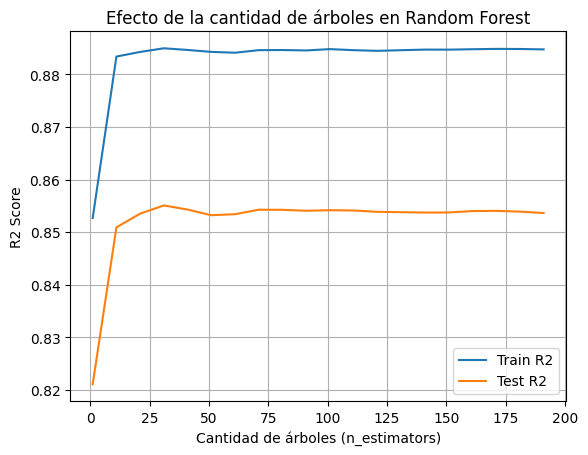

In [74]:

def analizar_arboles_rf(X_train, X_test, y_train, y_test, max_trees=200):
    
    estimators = range(1, max_trees + 1, 10)
    train_r2 = []
    test_r2 = []

    for n in estimators:
        model = RandomForestRegressor(n_estimators=n, random_state=42, max_depth=8, n_jobs=-1)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_r2.append(r2_score(y_train, y_train_pred))
        test_r2.append(r2_score(y_test, y_test_pred))

    # Gráfico
    plt.figure()
    plt.plot(estimators, train_r2, label="Train R2")
    plt.plot(estimators, test_r2, label="Test R2")

    # Actualizamos las etiquetas para reflejar el cambio
    plt.xlabel("Cantidad de árboles (n_estimators)")
    plt.ylabel("R2 Score")
    plt.title("Efecto de la cantidad de árboles en Random Forest")
    plt.legend()
    plt.grid()

    plt.show()


analizar_arboles_rf(x_train, x_val, y_train, y_val) 

Podemos observar que a medida que aumenta la cantidad de árboles, el rendimiento del modelo en el conjunto de validación aumenta, pero a partir de cierta cantidad de árboles, el rendimiento del modelo en el conjunto de validación se estabiliza, por ende, entre 50 y 100 arboles ya no presenta una mejora significativa.

In [75]:
random_forest = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
random_forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [76]:
y_pred_train_forest = modelo_forest.predict(x_train)
r2_train = r2_score(y_train, y_pred_train_forest)
mae_forest_train = mean_absolute_error(y_train, y_pred_train_forest)
print(f"R2 en el conjunto de entrenamiento: {r2_train}")
print(f"MAE en el conjunto de entrenamiento: {mae_forest_train}")

R2 en el conjunto de entrenamiento: 0.9216923145163415
MAE en el conjunto de entrenamiento: 857.4304986671427


In [77]:
y_pred_val_forest = modelo_forest.predict(x_val)
r2_val = r2_score(y_val, y_pred_val_forest)
mae_forest_val = mean_absolute_error(y_val, y_pred_val_forest)
print(f"R2 en el conjunto de validación: {r2_val}")
print(f"MAE en el conjunto de validación: {mae_forest_val}")

R2 en el conjunto de validación: 0.8734780095255037
MAE en el conjunto de validación: 1062.549630194082


In [78]:
y_pred_test_forest = modelo_forest.predict(x_test)
r2_test = r2_score(y_test, y_pred_test_forest)
mae_forest_test = mean_absolute_error(y_test, y_pred_test_forest)
print(f"R2 en el conjunto de prueba: {r2_test}")
print(f"MAE en el conjunto de prueba: {mae_forest_test}")

R2 en el conjunto de prueba: 0.8867555328343821
MAE en el conjunto de prueba: 1017.3352895007355


# Tabla resumen de resultados


| Modelo | R_2 (test) | R_2 (train) | MAE (test) |
| :--- | :--- | :--- | :--- |
| Regresión Lineal | 72% | 70%| 1763.8 |
| Árbol de Regresión | 84% | 87% | 1226.3 |
| Random Forest | 89% | 92% | 1017.3 |

## Comparacion de los modelos:


### Modelo con mejor rendimiento: ` Random Forest` 

El random forest posee un mejor rendimiento que el arbol de regresion y la regresion lineal, lo que se debe a que este modelo capta de mejor manera las relaciones no lineales entres las variables y tiene un mejor manejo del sobreajuste por la diferencia entre valores, esto es por el hecho de que el modelo utiliza varios arboles de regresión para hacer la predición, lo que reduce la varianza del modelo y permite asi una mejor generalización. 

### Modelo con peor rendimiento: `Regresión Lineal`

Este modelo presenta un gran problema, asume que la relaciones entre las variables y la variable objetivo es lineal, lo que al parecer no es el caso en este dataset. El modelo no es capaza de modelar bien las relaciones, haciendo el modelado más simple de lo que realmente es, generando un underfitting, lo que implica que el modelo no esta aprendiendo lo suficiente de los datos, lo que se refleja en su bajo rendimiento tanto en el conjunto de entrenamiento como en el conjunto de prueba. Además por eso, hay más r2 en el conjunto de prueba que en el conjunto de entrenamiento, lo que implica que el modelo esta presentando underfitting.

## ¿Por qué algunos modelos presentan un mejor rendimiento que otros?

Esto se debe a principalmente a los supuestos y la complejidades de cada modelo. Como se menciono anteriormente, el modelo de regresion lineal asume que existe una relacion lineal, el modelo de arbol de regresion asume que puedo dividir los datos utilizando ciertas regras, y el modelo de random forest, asume las reglas de un arbol de regresion pero utilizando varios arboles para hacer la prediccion. 

Como vimos en la primera parte, habian muchas variables con datos anomalos, lo que puede llegar afectar mucho a los modelos, ya que no pueden ser capaces de reconocer patrones en los datos, lo que puede llevar a un bajo rendimiento. Por lo tanto, es importante limpiar los datos y eliminar estos valores anormales para mejorar el rendimiento de los modelos.

## Posibles casos de underfitting y overfitting

En el modelo de regresion lineal, se puede observar claramente underfitting, ya que el modelo no esta aprendiendo tan bien los datos y esta considerando una relación mucho más simple de lo que realmente es, haciendo que el problema baje su complejdad verdaderamente, lo que se refleja en su bajo rendimiento tanto en el conjunto de entrenamiento como en el conjunto de prueba. Además por eso, hay más r2 en el conjunto de prueba que en el conjunto de entrenamiento, lo que implica que el modelo esta presentando underfitting.

En el modelo de arbol de regresion, se puede observar que a partir del hiperparametro  `profundidad`, si esta supera cierto valor, el modelo comienza a presentar overfitting, lo que significa que el modelo esta aprendiendo de memoria los datos y no esta generalizando bien.

Y el modelo de random forest llega para mejorar esto, ya que es menos propenso a presentar overfitting, lo que se debe a que este modelo ocupa varios arboles para reducir la varianza.

## ¿Qué significa la mae en este contexto?

La mae representa aproximadamente cuanto se equivoca el modelo al predecir un precio. Por ejemplo, si la mae es de 1000, implica que el modelo en promedio se equivoca en 1000uf al predecir el precio de una propiedad.

La mae es otra metrica que nos ayuda a decir que el mejor modelo es el random forest, ya que tiene la mae más baja, lo que implica que los errores cometidos no son tan grandes como los otros modelos. 

Igualmente el tamaño de la mae es sumamente relativo, por ejemplo, para propiedades con un precio grande, equivocarse solamente en 1000uf puede ser un error pequeño, pero para propiedades con un precio bajo, equivocarse en 1000 uf puede ser grande, por ende hay que tener encuenta el contexto del precio para analizar el tamaño de la mae.

## ¿Qué características podrían afectar el rendimiento del modelo de positiva o negativamente?

- `Valores atipicos`: La gran cantidad de valores atipicos presentes en el dataser puede afectar negativamente el rendimiento del modelo.

- `Variables irrelevantes`: Por ejemplo `direccion` y `direccion_2`, estas variables no aportan información relevante para predecir el precio, por lo tanto, pueden afectar negativamente el rendimiento del modelo si es que no se eliminan.

- `Variables con muchos valores nulos`: Por ejemplo `gastos_comunes`, esta variable posee una gran cantidad de valores nulos, lo que puede afectar negativamente el rendimiento del modelo si es que no se elimina o se hace imputing de los valores faltantes.

- `Variables con valores anormales`: Por ejemplo `year`, esta variable posee valores anormles la cual no poseen sentido (ejemplo año 0).

- `Inputing de los valores faltantes`: Hacer imputing de los valores faltantes puede afectar positivamente el rendimiento del modelo, ya que permite utilizar toda la información disponible en el dataset, lo que puede ayudar a mejorar el rendimiento del modelo. Pero a la vez hay que tener muchas precaucion, ya que si se incerta un valor que no es tan representativo puede afectar el rendimiento del modelo. Por ejemplo, si la mediana tuviera la misma cantidad de datos que otro valor, podria ser un valor no tan representativo, lo que puede afectar el rendimiento del modelo.

- `No hay una explicación clara de algunos valores que pueden tomar las variables`: Por ejemplo, en variables categoricas binarias, como `id_antiguedad`, no se sabe que significa cada valor y si puede ayudar o no al modelo.

## Referencias

- Seaborn. (s.f.). *histplot*. https://seaborn.pydata.org/generated/seaborn.histplot.html  

- Seaborn. (s.f.). *kdeplot*. https://seaborn.pydata.org/generated/seaborn.kdeplot.html  

- GraphPad Software. (s.f.). *Interpreting histograms and distributions*. https://www.graphpad.com/support/faqid/1577/  

- GeeksforGeeks. (s.f.). *Handling outliers with pandas*. https://www.geeksforgeeks.org/pandas/handling-outliers-with-pandas/  

- Sauro, J. (s.f.). *Z-score: Definition and interpretation*. MeasuringU. https://measuringu.com/z-score/  

- Stack Overflow. (s.f.). *How do I count the NaN values in a column in pandas DataFrame?* https://stackoverflow.com/questions/26266362/how-do-i-count-the-nan-values-in-a-column-in-pandas-dataframe  

- Scikit-learn. (s.f.). *Decision Trees*. https://scikit-learn.org/stable/modules/tree.html  

- Pontificia Universidad Católica de Chile. (s.f.). *Ayudantías [Material de curso]*. Canvas. https://cursos.canvas.uc.cl/courses/98804/files/folder/Ayudantías  

- Scikit-learn. (s.f.). *RandomForestRegressor*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html  